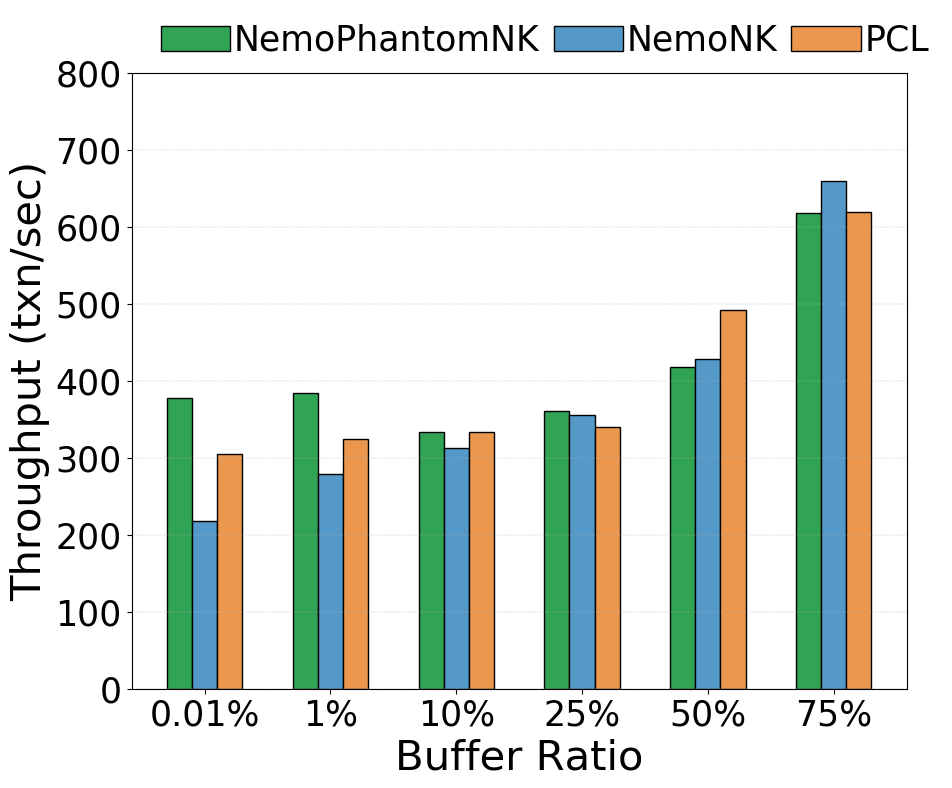

In [7]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c = line_colors["BLUE"] 
pcl_c = line_colors["ORANGE"]

# line_colors = {
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "NemoPhantomNK"
nemo_record_evict_label = "NemoNK"
pcl_label = "PCL"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_phantom_100m_varybuf_phantomnext_mixquery_nolog"
exp_tuple_record_evict = "exp_phantom_100m_varybuf_nextkey_mixquery_nolog"
exp_pcl = "exp_phantom_100m_varybuf_pcl_mixquery_nolog"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
# data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == 0]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)[:-1]
# print(df_tuple_batch)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
# data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == 0]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)[:-1]

data_pcl = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_pcl + ".txt")]
df_pcl = pd.DataFrame().from_records(data_pcl).sort_values(by=x_dimension)[:-1]


fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.2
indices = np.arange(len(df_tuple_batch))
offset = bar_width

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset , df_tuple_batch["throughput_txn_per_sec"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c,edgecolor='black')
record_bars = ax1.bar(indices, df_tuple_record["throughput_txn_per_sec"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c,edgecolor='black')
pcl_bars = ax1.bar(indices + offset, df_pcl["throughput_txn_per_sec"], bar_width, label=pcl_label, color=pcl_c,edgecolor='black')

# speedup = ((df_tuple_batch["throughput_txn_per_sec"] / 
#            df_tuple_record["throughput_txn_per_sec"] ) )

# for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
#     height = bar.get_height()
#     ax1.text(bar.get_x() + bar.get_width()/2, height,
#             f'{gain:.2f}x',
#             ha='center', va='bottom',
#             fontsize=ticksize-5)

ax1.set_xticks(indices)
# ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)


vals = df_tuple_batch[x_dimension] / (
        df_tuple_batch['g_record_size'] * df_tuple_batch['domain_size_'])

labels = [f'{v*100:.2f}%' if v < 0.01 else f'{v*100:.0f}%'
          for v in vals]

# (You should have called ax1.set_xticks(vals) earlier, or the
#  ticks won’t line up with these labels.)

ax1.set_xticklabels(labels, fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.set_ylim(0, 800)


ax1.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




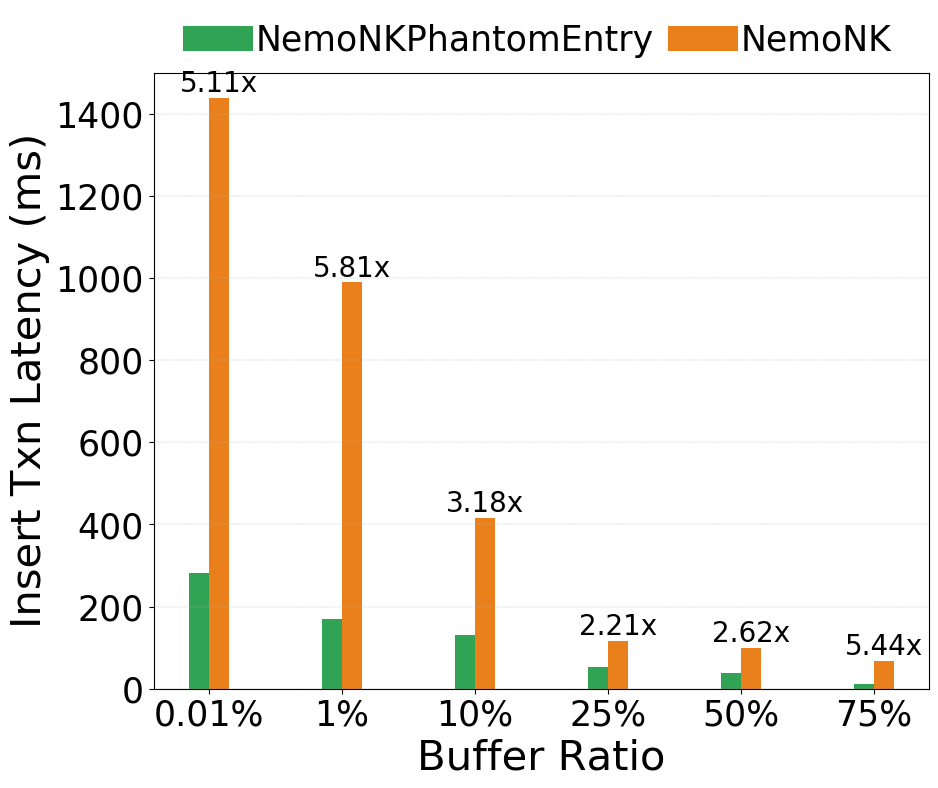

In [23]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "NemoNKPhantomEntry"
nemo_record_evict_label = "NemoNK"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_phantom_100m_varybuf_phantomnext_mixquery_nolog"
exp_tuple_record_evict = "exp_phantom_100m_varybuf_nextkey_mixquery_nolog"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
# data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == 0]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)[:-1]
# print(df_tuple_batch)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
# data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == 0]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)[:-1]

fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(df_tuple_batch))
offset = bar_width

# avg_sum_insert_txn_latency (us)
# insert_txn_latency_avg_us
measure =  "avg_sum_insert_txn_latency (us)"

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset/2 , df_tuple_batch[measure]*1.0/1000, bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices + offset/2, df_tuple_record[measure]*1.0/1000, bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)

# speedup = ((df_tuple_batch[measure] / 
#            df_tuple_record[measure] ) )


speedup = ((df_tuple_record[measure]/ df_tuple_batch[measure]) )

for idx, (bar, gain) in enumerate(zip(record_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)
ax1.set_xticks(indices)
# ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)


vals = df_tuple_batch[x_dimension] / (
        df_tuple_batch['g_record_size'] * df_tuple_batch['domain_size_'])

labels = [f'{v*100:.2f}%' if v < 0.01 else f'{v*100:.0f}%'
          for v in vals]

# (You should have called ax1.set_xticks(vals) earlier, or the
#  ticks won’t line up with these labels.)

ax1.set_xticklabels(labels, fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.set_ylim(0, 1500)


ax1.set_ylabel("Insert Txn Latency (ms)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




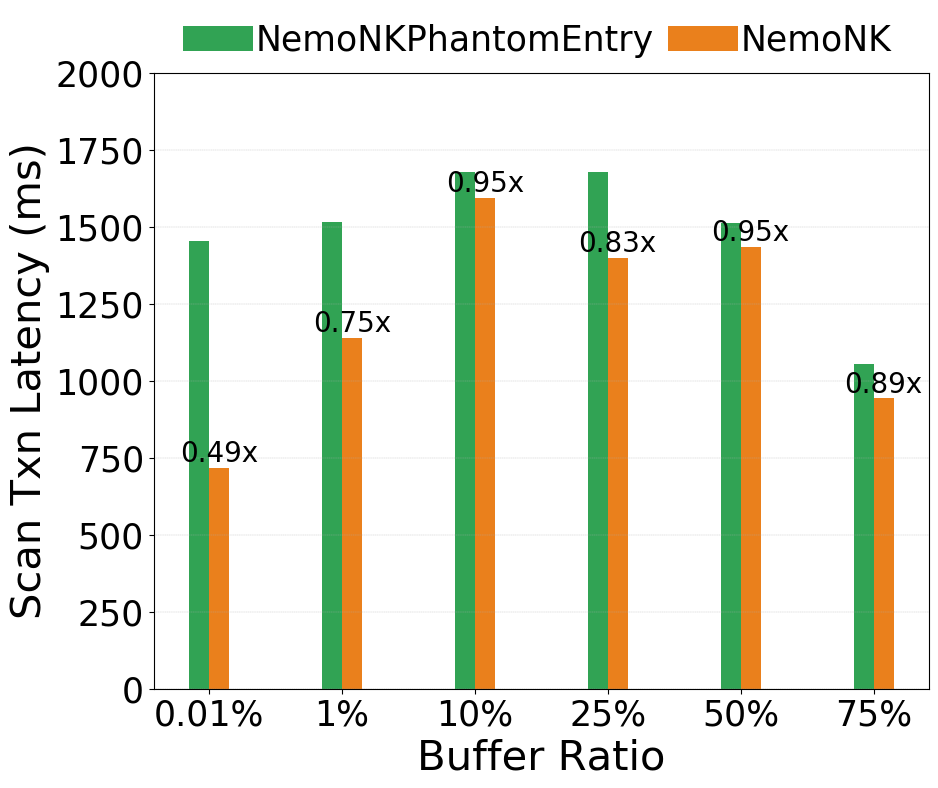

In [26]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "NemoNKPhantomEntry"
nemo_record_evict_label = "NemoNK"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_phantom_100m_varybuf_phantomnext_mixquery_nolog"
exp_tuple_record_evict = "exp_phantom_100m_varybuf_nextkey_mixquery_nolog"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
# data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == 0]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)[:-1]
# print(df_tuple_batch)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
# data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == 0]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)[:-1]

fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(df_tuple_batch))
offset = bar_width

# avg_sum_insert_txn_latency (us)
# insert_txn_latency_avg_us
measure =  "avg_sum_scan_txn_latency (us)"

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset/2 , df_tuple_batch[measure]*1.0/1000, bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices + offset/2, df_tuple_record[measure]*1.0/1000, bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)

# speedup = ((df_tuple_batch[measure] / 
#            df_tuple_record[measure] ) )


speedup = ((df_tuple_record[measure]/ df_tuple_batch[measure]) )

for idx, (bar, gain) in enumerate(zip(record_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)
ax1.set_xticks(indices)
# ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)


vals = df_tuple_batch[x_dimension] / (
        df_tuple_batch['g_record_size'] * df_tuple_batch['domain_size_'])

labels = [f'{v*100:.2f}%' if v < 0.01 else f'{v*100:.0f}%'
          for v in vals]

# (You should have called ax1.set_xticks(vals) earlier, or the
#  ticks won’t line up with these labels.)

ax1.set_xticklabels(labels, fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.set_ylim(0, 2000)


ax1.set_ylabel("Scan Txn Latency (ms)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




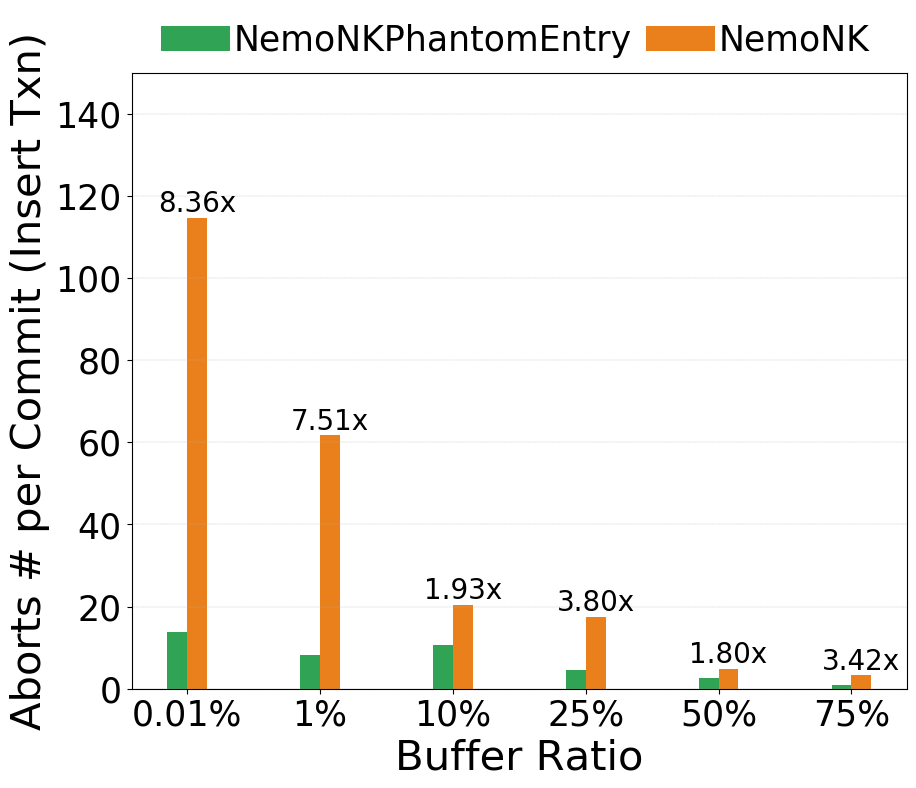

In [31]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "NemoNKPhantomEntry"
nemo_record_evict_label = "NemoNK"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_phantom_100m_varybuf_phantomnext_mixquery_nolog"
exp_tuple_record_evict = "exp_phantom_100m_varybuf_nextkey_mixquery_nolog"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
# data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == 0]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)[:-1]
# print(df_tuple_batch)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
# data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == 0]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)[:-1]

fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(df_tuple_batch))
offset = bar_width

# avg_sum_insert_txn_latency (us)
# insert_txn_latency_avg_us

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset/2 , df_tuple_batch["rw_abort_cnt_"]/df_tuple_batch["insert_commit_cnt_"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices + offset/2, df_tuple_record["rw_abort_cnt_"]/ df_tuple_record["insert_commit_cnt_"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)

# speedup = ((df_tuple_batch[measure] / 
#            df_tuple_record[measure] ) )


speedup = ((( df_tuple_record["rw_abort_cnt_"]/ df_tuple_record["insert_commit_cnt_"])/ (df_tuple_batch["rw_abort_cnt_"]/df_tuple_batch["insert_commit_cnt_"])) )

for idx, (bar, gain) in enumerate(zip(record_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)
ax1.set_xticks(indices)
# ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)


vals = df_tuple_batch[x_dimension] / (
        df_tuple_batch['g_record_size'] * df_tuple_batch['domain_size_'])

labels = [f'{v*100:.2f}%' if v < 0.01 else f'{v*100:.0f}%'
          for v in vals]

# (You should have called ax1.set_xticks(vals) earlier, or the
#  ticks won’t line up with these labels.)

ax1.set_xticklabels(labels, fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.set_ylim(0, 150)


ax1.set_ylabel("Aborts # per Commit (Insert Txn)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




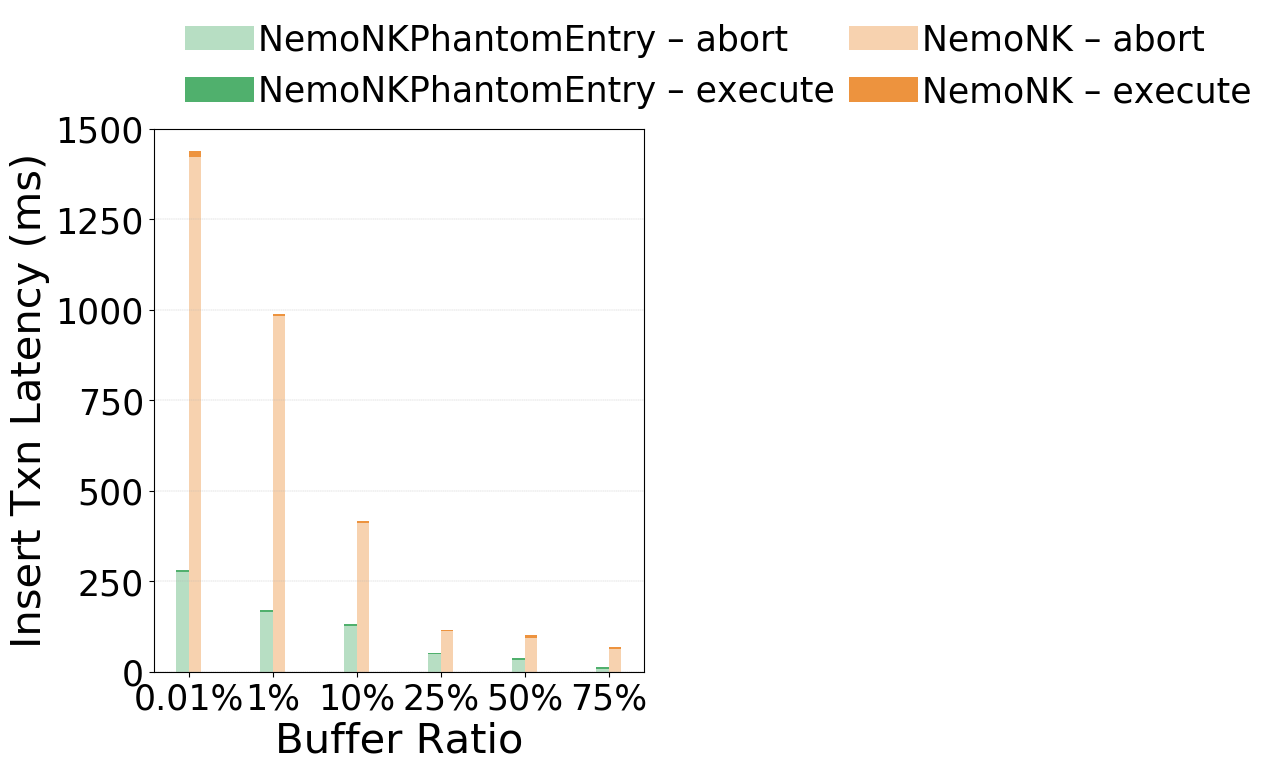

In [39]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize   = 30
ticksize  = 25
x_dimension = "g_total_buf_sz"

color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c  = "#31a354"
nemo_record_evict_c = "#ea801c"

nemo_batch_evict_label  = "NemoNKPhantomEntry"
nemo_record_evict_label = "NemoNK"

datadir = "../../output/"
exp_tuple_batch_evict  = "exp_phantom_100m_varybuf_phantomnext_mixquery_nolog"
exp_tuple_record_evict = "exp_phantom_100m_varybuf_nextkey_mixquery_nolog"

batch_json  = [json.loads(l) for l in open(datadir + exp_tuple_batch_evict  + ".txt")]
record_json = [json.loads(l.replace("inf", "0")) for l in open(datadir + exp_tuple_record_evict + ".txt")]

df_tuple_batch  = (pd.DataFrame.from_records(batch_json)
                   .sort_values(by=x_dimension)
                   .iloc[:-1])     # drop the 100 % row
df_tuple_record = (pd.DataFrame.from_records(record_json)
                   .sort_values(by=x_dimension)
                   .iloc[:-1])

measure    = "avg_sum_insert_txn_latency (us)"   # total latency (µs)
abort_col  = "avg_insert_abort_time_ (us)"       # abort latency (µs)

batch_abort   = df_tuple_batch [abort_col]                     / 1000   # ms
batch_exec    = (df_tuple_batch [measure] - df_tuple_batch [abort_col]) / 1000
record_abort  = df_tuple_record[abort_col]                     / 1000
record_exec   = (df_tuple_record[measure] - df_tuple_record[abort_col]) / 1000

fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
idx       = np.arange(len(df_tuple_batch))
off       = bar_width

# NemoNKPhantomEntry (batch) – stacked
ax1.bar(idx - off/2, batch_abort, bar_width,
        color=nemo_batch_evict_c, alpha=.35,
        label=f"{nemo_batch_evict_label} – abort")
ax1.bar(idx - off/2, batch_exec, bar_width, bottom=batch_abort,
        color=nemo_batch_evict_c, alpha=.85,
        label=f"{nemo_batch_evict_label} – execute")

# NemoNK (record) – stacked
rec_abort_bars = ax1.bar(idx + off/2, record_abort, bar_width,
                         color=nemo_record_evict_c, alpha=.35,
                         label=f"{nemo_record_evict_label} – abort")
rec_exec_bars  = ax1.bar(idx + off/2, record_exec, bar_width,
                         bottom=record_abort,
                         color=nemo_record_evict_c, alpha=.85,
                         label=f"{nemo_record_evict_label} – execute")

# speedup = df_tuple_record[measure] / df_tuple_batch[measure]
# for bar, gain in zip(rec_exec_bars, speedup):
#     top = bar.get_y() + bar.get_height()
#     ax1.text(bar.get_x() + bar.get_width()/2, top,
#              f"{gain:.2f}×", ha="center", va="bottom",
#              fontsize=ticksize-5)

ratio  = df_tuple_batch[x_dimension] / (
         df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"])
labels = [f"{v*100:.2f}%" if v < 0.01 else f"{v*100:.0f}%"
          for v in ratio]

ax1.set_xticks(idx)
ax1.set_xticklabels(labels, fontsize=ticksize)

ax1.tick_params(axis="y", labelsize=ticksize)
ax1.set_ylim(0, 1500)
ax1.set_ylabel("Insert Txn Latency (ms)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
ax1.grid(axis="y", linestyle="--", linewidth=0.25)

ax1.legend(fontsize=ticksize,
           bbox_to_anchor=(0.0, 1.15, 1.0, .102), loc=2,
           ncol=2, frameon=False, columnspacing=0.4,
           handletextpad=0.1)

plt.tight_layout()
plt.show()
